# 📊 04. RGB Testing CNN

Notebook ini mengevaluasi kinerja murni model CNN pada dataset testing CIFAR-10 (10.000 sampel).
Menampilkan metrik komprehensif: Loss, Accuracy, Precision, Recall, F1-Score, Classification Report, dan Confusion Matrix.


In [1]:
import os
import sys

# Setup CUDA DLL path sebelum import TensorFlow agar cuDNN terdeteksi sempurna
_cuda_bin = r'C:\Users\daffa\anaconda3\envs\CNNgpu\Library\bin'
if os.path.exists(_cuda_bin):
    if _cuda_bin not in os.environ.get('PATH', ''):
        os.environ['PATH'] = _cuda_bin + ';' + os.environ.get('PATH', '')
    if hasattr(os, 'add_dll_directory'):
        try:
            os.add_dll_directory(_cuda_bin)
        except Exception:
            pass

import json
import numpy as np
import tensorflow as tf

# Aktifkan GPU memory growth agar hemat VRAM & mencegah error 'DNN library is not found'
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
except Exception:
    pass


ARTIFACT_DIR = 'cifar10_artifacts/rgb'
model_path = os.path.join(ARTIFACT_DIR, 'custom_cnn_cifar10_final.keras')
if not os.path.exists(model_path):
    model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')

print(f"Memuat model CNN dari: {model_path}")
cnn_model = tf.keras.models.load_model(model_path)
print(f"Model berhasil dimuat: {cnn_model.name}")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def load_cifar10_test_data():
    _, (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
    X_test = X_test.astype('float32') / 255.0
    y_test = y_test.flatten()
    return X_test, y_test

def evaluate_classification(y_true, y_pred, title='Model Evaluation', plot_cm=True, save_cm_path=None):
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print('=================================================================')
    print(f'  {title.upper()}')
    print('=================================================================')
    print(f'  Accuracy           : {acc * 100:.2f}% ({acc:.4f})')
    print(f'  Precision (Macro)  : {prec_macro * 100:.2f}% ({prec_macro:.4f})')
    print(f'  Recall (Macro)     : {rec_macro * 100:.2f}% ({rec_macro:.4f})')
    print(f'  F1-Score (Macro)   : {f1_macro * 100:.2f}% ({f1_macro:.4f})')
    print('-----------------------------------------------------------------')
    print(f'  Precision (Weight) : {prec_weighted * 100:.2f}% ({prec_weighted:.4f})')
    print(f'  Recall (Weight)    : {rec_weighted * 100:.2f}% ({rec_weighted:.4f})')
    print(f'  F1-Score (Weight)  : {f1_weighted * 100:.2f}% ({f1_weighted:.4f})')
    print('=================================================================')
    print('\n--- CLASSIFICATION REPORT ---')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    if plot_cm:
        plt.figure(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.title(f'Confusion Matrix: {title}', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.tight_layout()
        if save_cm_path:
            os.makedirs(os.path.dirname(save_cm_path), exist_ok=True)
            plt.savefig(save_cm_path, dpi=200)
            print(f'[INFO] Confusion Matrix heatmap disimpan ke: {save_cm_path}')
        plt.show()

    return {
        'accuracy': float(acc),
        'precision_macro': float(prec_macro),
        'recall_macro': float(rec_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(prec_weighted),
        'recall_weighted': float(rec_weighted),
        'f1_weighted': float(f1_weighted),
        'confusion_matrix': cm.tolist()
    }


Memuat model CNN dari: cifar10_artifacts/rgb\custom_cnn_cifar10_final.keras
Model berhasil dimuat: cnn_3ch


## 📥 1. Evaluasi pada Test Set CIFAR-10 RGB
Memuat murni 10.000 data testing (hemat RAM, bebas MemoryError).

In [2]:
# Memuat hanya data testing 10.000 sampel untuk menghemat memori RAM
X_test, y_test = load_cifar10_test_data()
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

print("Mengevaluasi performa CNN pada 10.000 sampel testing...")
try:
    cnn_eval = cnn_model.evaluate(X_test, y_test_cat, batch_size=128, verbose=1)
    y_pred_probs = cnn_model.predict(X_test, batch_size=128, verbose=0)
except Exception as e:
    print(f"Evaluasi GPU terkendala ({e}), mengevaluasi via CPU...")
    with tf.device('/CPU:0'):
        cnn_eval = cnn_model.evaluate(X_test, y_test_cat, batch_size=128, verbose=1)
        y_pred_probs = cnn_model.predict(X_test, batch_size=128, verbose=0)

print(f"CNN Test Loss     : {cnn_eval[0]:.4f}")
print(f"CNN Test Accuracy : {cnn_eval[1] * 100:.2f}%")

y_pred_cnn = np.argmax(y_pred_probs, axis=-1)


Mengevaluasi performa CNN pada 10.000 sampel testing...
79/79 [==============================] - 8s 25ms/step - loss: 0.8086 - accuracy: 0.9225 - precision: 0.9365 - recall: 0.9118
CNN Test Loss     : 0.8086
CNN Test Accuracy : 92.25%


## 📊 2. Classification Report & Confusion Matrix (CNN)


  RGB CNN EVALUATION
  Accuracy           : 92.25% (0.9225)
  Precision (Macro)  : 92.28% (0.9228)
  Recall (Macro)     : 92.25% (0.9225)
  F1-Score (Macro)   : 92.19% (0.9219)
-----------------------------------------------------------------
  Precision (Weight) : 92.28% (0.9228)
  Recall (Weight)    : 92.25% (0.9225)
  F1-Score (Weight)  : 92.19% (0.9219)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    airplane     0.9303    0.9350    0.9327      1000
  automobile     0.9633    0.9720    0.9676      1000
        bird     0.9229    0.8980    0.9103      1000
         cat     0.8713    0.7990    0.8336      1000
        deer     0.9332    0.9220    0.9276      1000
         dog     0.9059    0.8470    0.8755      1000
        frog     0.8642    0.9800    0.9185      1000
       horse     0.9457    0.9580    0.9518      1000
        ship     0.9643    0.9460    0.9551      1000
       truck     0.9263    0.9680    0.9467      1000

    accuracy 

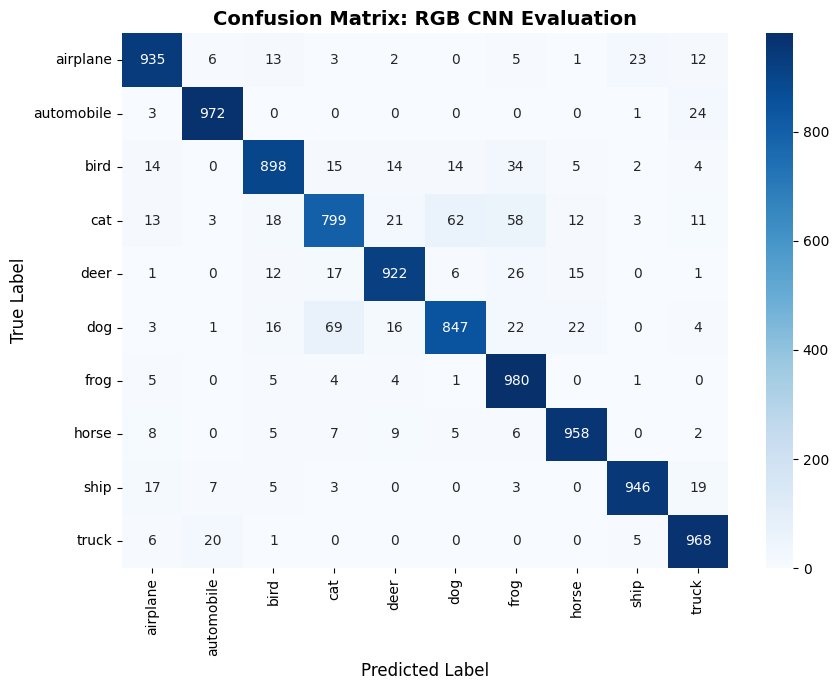

In [3]:
cm_path = os.path.join(ARTIFACT_DIR, 'confusion_matrix_cnn.png')
metrics_cnn = evaluate_classification(
    y_true=y_test,
    y_pred=y_pred_cnn,
    title="RGB CNN Evaluation",
    plot_cm=True,
    save_cm_path=cm_path
)

with open(os.path.join(ARTIFACT_DIR, 'metrics_cnn.json'), 'w') as f:
    json.dump(metrics_cnn, f, indent=2)
